# Principal Component Analysis Lab

In [37]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('M3 - b5 - b5.csv')
df.head()

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
0,4,2,5,2,5,1,4,3,5,1,1,5,2,5,1,1,1,1,1,1,1,5,1,5,2,3,1,5,4,5,4,1,5,1,5,1,4,1,4,5,4,1,3,1,5,1,4,2,5,5
1,2,2,3,3,3,3,1,5,1,5,2,3,4,2,3,4,3,2,2,4,1,3,3,4,4,4,2,3,4,3,4,1,3,2,3,1,5,1,4,4,3,3,3,3,2,3,3,1,3,2
2,5,1,1,4,5,1,1,5,5,1,5,1,5,5,5,5,5,5,5,5,5,1,5,5,1,5,1,5,5,5,4,1,5,1,5,1,5,1,5,5,4,5,5,1,5,1,5,5,5,5
3,2,5,2,4,3,4,3,4,4,5,5,4,4,2,4,5,5,5,4,5,2,5,4,4,3,5,3,4,4,3,3,3,4,5,1,4,5,4,2,3,4,3,5,2,4,2,5,2,5,5
4,3,1,3,3,3,1,3,1,3,5,3,3,3,4,3,3,3,3,3,4,5,5,3,5,1,5,1,5,5,5,3,1,5,3,3,1,1,3,3,3,3,1,1,1,3,1,3,1,5,3


In [3]:
df.describe()

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
count,18930.000000,18930.000000,18930.00000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000,18930.000000
mean,2.630375,2.759113,3.41775,3.151981,3.433228,2.450819,2.869995,3.376440,3.092446,3.585156,3.261701,3.237084,3.842367,2.754939,2.949921,2.978130,3.151453,2.802377,3.131115,2.833545,2.309826,3.929054,2.163761,4.032118,2.162863,3.894031,2.157369,3.768146,3.942631,3.680032,3.318859,2.985050,3.983782,2.658954,2.695985,2.926466,3.645959,2.483941,3.221764,3.635763,3.695985,2.146804,4.127787,2.074908,3.872055,1.794506,4.075225,3.211939,4.135394,4.006075
std,1.231010,1.312125,1.23533,1.221943,1.281626,1.240543,1.430686,1.265017,1.395642,1.302745,1.308375,1.176845,1.138876,1.222082,1.272326,1.319541,1.299406,1.350422,1.299361,1.313352,1.367724,1.077035,1.214584,1.044230,1.140620,1.130677,1.130322,1.033983,1.085536,1.052004,1.098589,1.366582,1.001611,1.242277,1.247352,1.398694,1.151001,1.132083,1.246031,1.011258,1.114061,1.132116,1.006658,1.107746,0.940687,1.068241,0.920613,1.256600,0.980554,0.984166
min,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.00000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,1.000000,4.000000,1.000000,3.000000,1.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000,3.000000,1.000000,4.000000,1.000000,3.000000,1.000000,4.000000,2.000000,4.000000,3.000000
50%,3.000000,3.000000,4.00000,3.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,4.000000,2.000000,4.000000,2.000000,4.000000,2.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,2.000000,3.000000,4.000000,4.000000,2.000000,4.000000,2.000000,4.000000,1.000000,4.000000,3.000000,4.000000,4.000000
75%,4.000000,4.000000,4.00000,4.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,3.000000,5.000000,3.000000,5.000000,3.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,3.000000,4.000000,4.000000,5.000000,3.000000,5.000000,3.000000,5.000000,2.000000,5.000000,4.000000,5.000000,5.000000
max,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [8]:
df.isnull().sum().sum()

np.int64(0)

Creating the covariant matrix

In [ ]:
cov_matrix = df.cov()
print(cov_matrix)

           E1        E2        E3  ...        O8        O9       O10
E1   1.515386 -0.681943  0.725025  ...  0.009347 -0.099828  0.201781
E2  -0.681943  1.721673 -0.723232  ... -0.033312  0.087823 -0.180480
E3   0.725025 -0.723232  1.526041  ... -0.115009 -0.107808  0.146176
E4  -0.731132  0.847801 -0.731305  ...  0.007674  0.135056 -0.156716
E5   0.759063 -0.906518  0.934705  ...  0.023345 -0.034094  0.244449
E6  -0.530330  0.927399 -0.602994  ... -0.168878 -0.015238 -0.313162
E7   1.038531 -0.903155  1.026208  ...  0.020898 -0.077754  0.233237
E8  -0.570873  0.620031 -0.498700  ... -0.025161  0.106672 -0.146827
E9   0.784080 -0.668152  0.730358  ...  0.087438 -0.052667  0.273674
E10 -0.667371  0.792610 -0.767521  ... -0.012872  0.144025 -0.169808
N1  -0.184578  0.103088 -0.377703  ...  0.037881  0.144660 -0.118184
N2   0.219604 -0.049495  0.408481  ... -0.032447 -0.067233  0.109078
N3  -0.169262  0.085012 -0.279594  ...  0.018988  0.197211 -0.067931
N4   0.205838 -0.109910  0.303288 

Calculating the eigenvalues and eigen vectors

In [10]:
eigenVal, eigenVec = np.linalg.eigh(cov_matrix)
print("Eigenvalues:")
print(eigenVal)

print("\nEigenvectors:")
print(eigenVec)


Eigenvalues:
[ 0.31633867  0.36967745  0.38914351  0.435093    0.4553634   0.46638907
  0.47748673  0.53984626  0.56030902  0.57114003  0.57799435  0.59164439
  0.61038695  0.62779672  0.63548546  0.63915242  0.64524573  0.65768216
  0.66395621  0.68773532  0.70447904  0.71952176  0.73742226  0.76191973
  0.78908819  0.79963375  0.81585482  0.82863661  0.84745285  0.88664327
  0.90877913  0.93139012  0.97578645  0.98117481  1.01915409  1.08342432
  1.14558146  1.18676516  1.26068773  1.30584677  1.38764108  1.4505845
  1.53655585  1.8603724   2.23010868  4.03531201  4.22917147  5.28661164
  7.21948567 12.32790254]

Eigenvectors:
[[-2.90243904e-02  8.76614529e-03 -2.13105181e-02 ...  7.81383843e-02
   1.78898864e-01 -1.87185677e-01]
 [-9.95684868e-05 -6.33692511e-03 -1.62713179e-02 ... -5.36722176e-02
  -2.27291859e-01  1.95215094e-01]
 [-1.46048412e-02 -6.01428308e-02 -9.57290124e-04 ...  1.98208934e-03
   1.07460298e-01 -2.52861667e-01]
 ...
 [ 3.87736779e-02  4.71367744e-02  4.442149

In [25]:
eigenSorted = np.argsort(eigenVal)[::-1]
eigenValues = eigenSorted
eigenVectors = eigenVec[:,eigenSorted]


# Implementing the PCA

In [32]:
#creating a PCA object
pca = PCA(n_components=2)
#fit and transform teh data onto the model
X_pca = pca.fit_transform(df)

In [33]:
df.shape

(18930, 50)

In [34]:
X_pca.shape

(18930, 2)

In [35]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,8.984244,-2.855104
1,-1.879690,-3.634597
2,-0.545564,3.148957
3,-5.161583,2.764500
4,1.200653,0.790370


# Graphing the two components pca1 and pca2

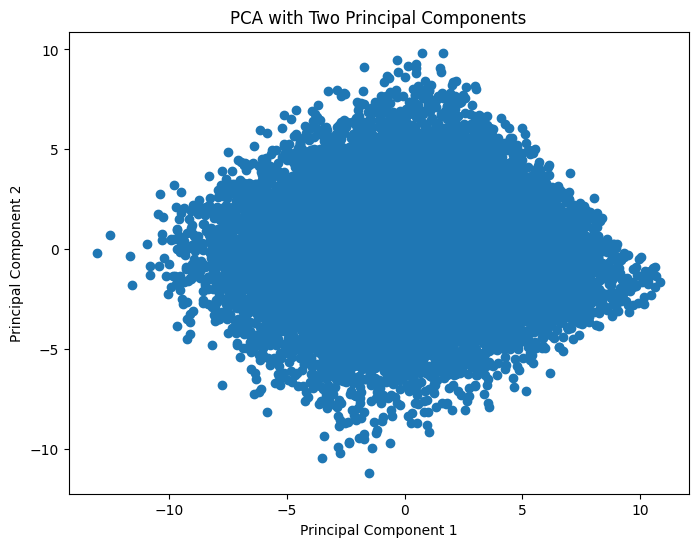

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(pca_df["PC1"], pca_df["PC2"])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA with Two Principal Components")

plt.show()